In [1]:
#import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
#load dataset
df = pd.read_csv('/content/penguins.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [4]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [5]:
df.shape

(344, 7)

In [6]:
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,10


In [7]:
#remove null values
df = df.dropna()

In [8]:
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


In [9]:
print("No.of records:", df.duplicated().sum())

No.of records: 0


In [10]:
#remove duplicate records
df.drop_duplicates(inplace=True)
df.shape

(334, 7)

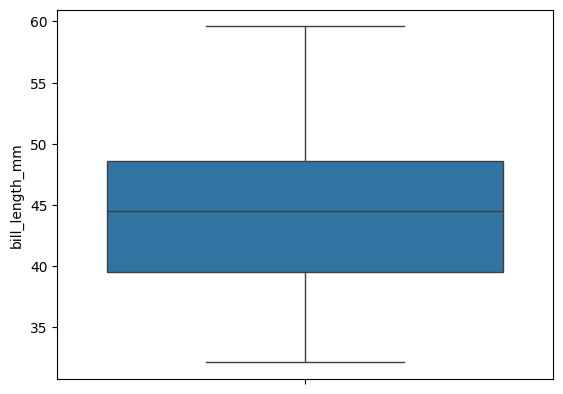

In [15]:
#identify outliers
sns.boxplot(df['bill_length_mm'])
plt.show()

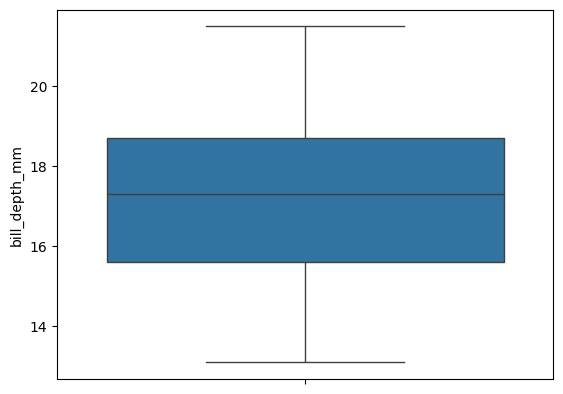

In [12]:
#identify outliers in bill depth
sns.boxplot(df['bill_depth_mm'])
plt.show()

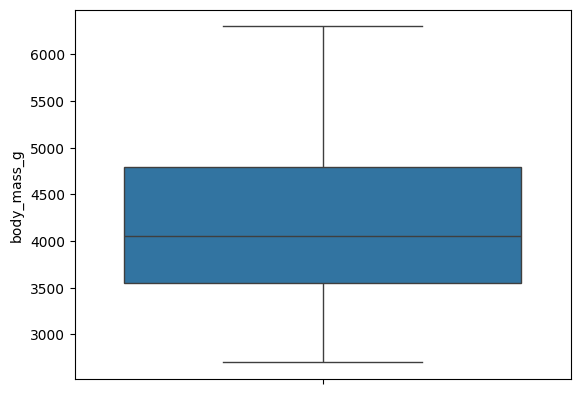

In [13]:
#identify body mass
sns.boxplot(df['body_mass_g'])
plt.show()

In [17]:
#label encoding for target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])


In [18]:
x = df[['bill_length_mm',
        'bill_depth_mm',
        'flipper_length_mm',
        'body_mass_g']]

y = df['species']

In [19]:
#split the data into training and testing
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.20,
    random_state=15
)

In [20]:
#standardization
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [21]:
#model building
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [25]:
#predictions on test data
y_pred=knn.predict(x_test)

In [24]:
#evaluation metrics
y_pred = knn.predict(x_test)

print("Accuracy:", accuracy_score(y_test,y_pred))

print("Classification Report:")
print(classification_report(y_test,y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test,y_pred))

Accuracy: 0.9701492537313433
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        29
           1       0.94      0.94      0.94        16
           2       1.00      1.00      1.00        22

    accuracy                           0.97        67
   macro avg       0.97      0.97      0.97        67
weighted avg       0.97      0.97      0.97        67

Confusion Matrix:
[[28  1  0]
 [ 1 15  0]
 [ 0  0 22]]


<Axes: >

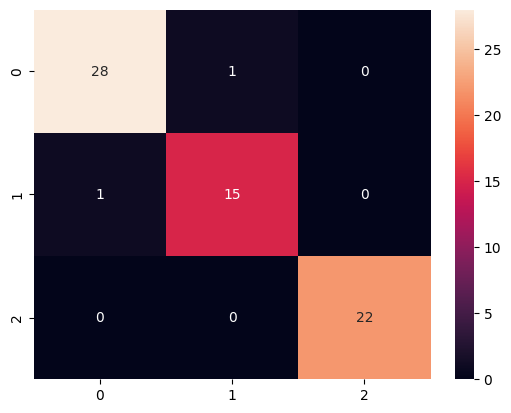

In [26]:
#confusion matrix
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

In [27]:
from sklearn.metrics import accuracy_score, roc_auc_score
y_pred = knn.predict(x_test)
y_proba = knn.predict_proba(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
roc_auc = roc_auc_score(
y_test,
y_proba,
multi_class='ovr'
)
print("ROC-AUC Score:", roc_auc)

Accuracy: 0.9701492537313433
ROC-AUC Score: 0.9992890229291959


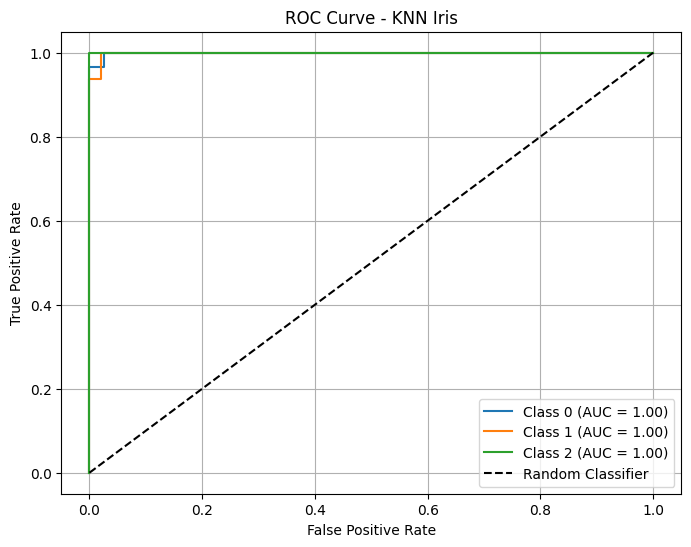

In [28]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities
y_proba = knn.predict_proba(x_test)

# Convert test labels into binary form
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc_score = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(
        fpr, tpr,
        label=f'Class {i} (AUC = {auc_score:.2f})'
    )

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN Iris')
plt.legend()
plt.grid()
plt.show()

In [30]:
overall_auc = roc_auc_score(
y_test_bin,y_proba,
multi_class='ovr'
)
print("Overall ROC-AUC:", overall_auc)

Overall ROC-AUC: 0.9992890229291959
